# Time Series Pipeline — U.S. House Results
This notebook builds a time series of U.S. House election results interpolated 
onto the 2026 congressional district boundaries using population-weighted interpolation.

## How to use this notebook
1. Set your county parameters in the Configuration section below
2. Download the MEDSL election files (links in Issue #10) and VEST 2016/2018 shapefiles and place in data/raw/election_results/
3. Run all cells top to bottom
4. Outputs will be saved to data/processed/ with your county name in the filename

## Data sources
- Boundary files: data/raw/boundaries/ (TLC 2020, 2022, 2024 — already in repo)
- VEST boundary files: data/raw/election_results/ (tx_2016.zip, tx_2018.zip — download from VEST Harvard Dataverse https://doi.org/10.7910/DVN/NH5S2I and https://doi.org/10.7910/DVN/UBKYRU)
- Election results: MEDSL — see Issue #10 for download links
- Census blocks: data/raw/census/ (already in repo)

In [1]:
# =============================================================================
# CONFIGURATION — change these values for your county
# =============================================================================

COUNTY_FIPS = 85
COUNTY_NAME = 'COLLIN'

# Output prefix for saved files
COUNTY_SLUG = COUNTY_NAME.lower().replace(' ', '_')  # e.g. 'travis', 'harris', 'tarrant'

print(f"Running pipeline for: {COUNTY_NAME} County (FIPS: {COUNTY_FIPS})")

Running pipeline for: COLLIN County (FIPS: 85)


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import zipfile
import os

print("Libraries loaded")

Libraries loaded


## Step 1 — Load boundary files

We need five boundary files, one per election cycle:
- 2016 precinct boundaries: VEST 2016 shapefile (tx_2016.zip)
- 2018 precinct boundaries: VEST 2018 shapefile (tx_2018.zip)
- 2020 precinct boundaries: TLC 2020 shapefile
- 2022 precinct boundaries: TLC 2022 shapefile
- 2024 precinct boundaries: TLC 2024 shapefile

Using cycle-specific boundary files ensures population weights are calculated 
using the precinct shapes that were actually in use during each election.

All boundary files cover all Texas counties — we filter to our county using CNTY.

In [4]:
# =============================================================================
# STEP 1 — Load boundary files
# =============================================================================

# 2016 precinct boundaries — VEST shapefile
precincts_2016 = gpd.read_file('zip://../data/raw/election_results/tx_2016.zip!tx_2016.shp')
precincts_2016 = precincts_2016[precincts_2016['CNTY'] == COUNTY_FIPS].copy()
print(f"2016 precincts: {len(precincts_2016)}")

# 2018 precinct boundaries — VEST shapefile
precincts_2018 = gpd.read_file('zip://../data/raw/election_results/tx_2018.zip!tx_2018.shp')
precincts_2018 = precincts_2018[precincts_2018['CNTY'] == COUNTY_FIPS].copy()
print(f"2018 precincts: {len(precincts_2018)}")

# 2020 precinct boundaries — TLC shapefile
precincts_2020 = gpd.read_file('zip://../data/raw/boundaries/precincts20g_2020.zip!Precincts20G_2020.shp')
precincts_2020 = precincts_2020[precincts_2020['CNTY'] == COUNTY_FIPS].copy()
print(f"2020 precincts: {len(precincts_2020)}")

# 2022 precinct boundaries — TLC shapefile
precincts_2022 = gpd.read_file('zip://../data/raw/boundaries/precincts22g.zip!Precincts22G.shp')
precincts_2022 = precincts_2022[precincts_2022['CNTY'] == COUNTY_FIPS].copy()
print(f"2022 precincts: {len(precincts_2022)}")

# 2024 precinct boundaries — TLC shapefile
precincts_2024 = gpd.read_file('zip://../data/raw/boundaries/precincts24g.zip!Precincts24G.shp')
precincts_2024 = precincts_2024[precincts_2024['CNTY'] == COUNTY_FIPS].copy()
print(f"2024 precincts: {len(precincts_2024)}")

2016 precincts: 214
2018 precincts: 226
2020 precincts: 239
2022 precincts: 248
2024 precincts: 252


## Step 2 — Load 2026 congressional district boundaries

These are the target geography — the new district boundaries we want to 
translate historical results onto.

In [5]:
# =============================================================================
# STEP 2 — Load 2026 congressional district boundaries
# =============================================================================

districts = gpd.read_file('zip://../data/raw/boundaries/PLANC2333.zip!PLANC2333/PLANC2333.shp')
print(f"Total 2026 districts: {len(districts)}")
print(f"Columns: {list(districts.columns)}")

print(f"\nDistricts CRS: {districts.crs}")
print(f"Precincts CRS: {precincts_2020.crs}")

Total 2026 districts: 38
Columns: ['District', 'geometry']

Districts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Precincts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4

## Step 3 — Load census block population data

Census blocks are the bridge between precinct boundaries and district boundaries.
Each block has an exact population count and sits entirely within one precinct 
and one district — allowing us to calculate population-weighted splits.

We use 2020 Census blocks for all election cycles (most recent available).

In [10]:
# =============================================================================
# STEP 3 — Load census block population data
# =============================================================================

blocks = gpd.read_file('zip://../data/raw/census/Blocks.zip!Blocks.shp')
blocks = blocks[blocks['CNTY'] == str(COUNTY_FIPS).zfill(3)].copy()
print(f"Census blocks: {len(blocks)}")

# Load population counts
pop = pd.read_csv('../data/raw/census/Blocks_Pop.txt', dtype={'SCTBKEY': str})
pop = pop[pop['SCTBKEY'].str.startswith('48' + str(COUNTY_FIPS).zfill(3))].copy()
print(f"Population records: {len(pop)}")

# Join population to blocks
blocks = blocks.merge(pop[['SCTBKEY', 'total']], on='SCTBKEY', how='left')
blocks['total'] = blocks['total'].fillna(0)
print(f"Total population: {blocks['total'].sum():,.0f}")

Census blocks: 16324
Population records: 16324
Total population: 1,064,465


## Step 4 — Build weights tables

We build one weights table per election cycle using the precinct boundaries 
that were in use during that election:

- 2016 weights: uses VEST 2016 precinct boundaries
- 2018 weights: uses VEST 2018 precinct boundaries
- 2020 weights: uses TLC 2020 precinct boundaries
- 2022 weights: uses TLC 2022 precinct boundaries
- 2024 weights: uses TLC 2024 precinct boundaries

Each weights table tells us what fraction of each precinct's population
falls inside each 2026 congressional district.

Note: Precinct boundaries changed between some cycles. Using cycle-specific 
boundary files ensures accuracy. For Travis County, VEST geometry analysis 
showed <0.2% population impact from boundary changes between 2016 and 2020.

In [23]:
# =============================================================================
# STEP 4 — Build weights tables
# =============================================================================

def build_weights_table(precincts, districts, blocks, label):
    """
    Build a population-weighted interpolation table for a given set of 
    precinct boundaries intersected with 2026 congressional districts.
    
    Parameters:
        precincts: GeoDataFrame of precinct boundaries
        districts: GeoDataFrame of 2026 congressional district boundaries
        blocks: GeoDataFrame of census blocks with population counts
        label: string label for print statements (e.g. '2020')
    
    Returns:
        DataFrame with columns: old_precinct_id, new_district_id, 
                                fragment_population, weight
    """
    
    # Reproject all to same CRS
    districts_proj = districts.to_crs(precincts.crs)
    blocks_proj = blocks.to_crs(precincts.crs)
    
    # Tag each block with its precinct
    blocks_with_precinct = gpd.sjoin(
        blocks_proj,
        precincts[['PCTKEY', 'geometry']],
        how='left',
        predicate='intersects'
    )
    blocks_with_precinct = blocks_with_precinct.drop(columns=['index_right'])
    
    # Tag each block with its district
    blocks_with_both = gpd.sjoin(
        blocks_with_precinct,
        districts_proj[['District', 'geometry']],
        how='left',
        predicate='intersects'
    )
    
    # Calculate fragment populations
    fragments = blocks_with_both.groupby(
        ['PCTKEY', 'District']
    )['total'].sum().reset_index()
    fragments.columns = ['old_precinct_id', 'new_district_id', 'fragment_population']
    
    # Calculate weights
    precinct_totals = fragments.groupby('old_precinct_id')['fragment_population'].sum()
    fragments['precinct_total'] = fragments['old_precinct_id'].map(precinct_totals)
    fragments['weight'] = fragments['fragment_population'] / fragments['precinct_total']
    
    # Validate
    weight_sums = fragments.groupby('old_precinct_id')['weight'].sum()
    valid = weight_sums[weight_sums.round(6) != 1.0]
    print(f"{label} weights table: {len(fragments)} rows")
    print(f"{label} weight validation — precincts not summing to 1.0: {len(valid)}")
    
    return fragments

# Build weights tables — one per election cycle using cycle-specific boundaries
weights_2016 = build_weights_table(precincts_2016, districts, blocks, '2016')
weights_2018 = build_weights_table(precincts_2018, districts, blocks, '2018')
weights_2020 = build_weights_table(precincts_2020, districts, blocks, '2020')
weights_2022 = build_weights_table(precincts_2022, districts, blocks, '2022')
weights_2024 = build_weights_table(precincts_2024, districts, blocks, '2024')

2016 weights table: 301 rows
2016 weight validation — precincts not summing to 1.0: 0
2018 weights table: 316 rows
2018 weight validation — precincts not summing to 1.0: 0
2020 weights table: 332 rows
2020 weight validation — precincts not summing to 1.0: 0
2022 weights table: 347 rows
2022 weight validation — precincts not summing to 1.0: 0
2024 weights table: 352 rows
2024 weight validation — precincts not summing to 1.0: 0


## Note — 2018 boundary patch for Collin County

The VEST 2018 Texas shapefile contains only 226 Collin County precincts, but MEDSL 
2018 election results reference 239 precincts (227-239 missing from VEST). 

This appears to be a genuine gap in VEST's source data — Collin County's election 
office likely added these precincts during 2018 boundary adjustments that didn't 
make it into VEST's published file, even after their most recent revision (V64, 
last updated July 2025).

We patch this by using the 2020 TLC boundary shapes for the 13 missing precincts, 
since they exist with stable identifiers in that file. This is a reasonable 
approximation but introduces minor uncertainty for those specific precincts in 2018 — 
their actual 2018 boundaries may have differed slightly from their 2020 boundaries.

Affected precincts: 850227–850239 (13 of 239 total, representing the missing votes)

In [24]:
# =============================================================================
# Patch 2018 weights table — VEST 2018 boundary file is missing 13 precincts
# that exist in MEDSL 2018 results. Using 2020 TLC shapes for those precincts
# as the best available approximation.
# =============================================================================

missing_2018 = set(results_2018['PCTKEY'].unique()) - set(weights_2018['old_precinct_id'].astype(str).unique())
print(f"Missing 2018 precincts: {sorted(missing_2018)}")

# Get those precincts from the 2020 boundary file
precincts_2020_padded = precincts_2020.copy()
precincts_2020_padded['PCTKEY_clean'] = precincts_2020_padded['PCTKEY'].astype(str).str.lstrip('0')
patch_precincts = precincts_2020_padded[precincts_2020_padded['PCTKEY_clean'].isin(missing_2018)].copy()
patch_precincts['PCTKEY'] = patch_precincts['PCTKEY_clean']
patch_precincts = patch_precincts.drop(columns=['PCTKEY_clean'])

print(f"Found {len(patch_precincts)} precincts in 2020 boundary file to patch in")

# Build weights for just the patch precincts
weights_2018_patch = build_weights_table(patch_precincts, districts, blocks, '2018 patch')

# Combine with original 2018 weights
weights_2018 = pd.concat([weights_2018, weights_2018_patch], ignore_index=True)
print(f"\nFinal 2018 weights table: {len(weights_2018)} rows")

Missing 2018 precincts: ['850227', '850228', '850229', '850230', '850231', '850232', '850233', '850234', '850235', '850236', '850237', '850238', '850239']
Found 13 precincts in 2020 boundary file to patch in
2018 patch weights table: 18 rows
2018 patch weight validation — precincts not summing to 1.0: 0

Final 2018 weights table: 334 rows


In [25]:
# Check which precincts don't sum to 1.0 across years
for label, weights in [('2016', weights_2016), ('2018', weights_2018), ('2020', weights_2020)]:
    weight_sums = weights.groupby('old_precinct_id')['weight'].sum()
    invalid = weight_sums[weight_sums.round(6) != 1.0]
    print(f"{label} invalid precincts: {list(invalid.index)}")

2016 invalid precincts: []
2018 invalid precincts: []
2020 invalid precincts: []


## Step 5 — Save weights tables

In [26]:
# =============================================================================
# STEP 5 — Save weights tables
# =============================================================================
weights_2016.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2016.csv', index=False)
weights_2018.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2018.csv', index=False)
weights_2020.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2020.csv', index=False)
weights_2022.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2022.csv', index=False)
weights_2024.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2024.csv', index=False)
print(f"Saved {COUNTY_SLUG}_population_weights_2016.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2018.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2020.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2022.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2024.csv")

Saved collin_population_weights_2016.csv
Saved collin_population_weights_2018.csv
Saved collin_population_weights_2020.csv
Saved collin_population_weights_2022.csv
Saved collin_population_weights_2024.csv


## Step 6 — Load election results

We load U.S. House precinct-level results from MEDSL for each election cycle.
Each file covers all Texas counties — we filter to our county using county_name.

Note on 2016: the file uses different column names (state_postal, party) 
compared to later years (state_po, party_simplified). County names are also 
in title case (e.g. "Travis County") rather than uppercase ("TRAVIS").

Note on 2022/2024: MEDSL files may contain split precinct IDs with letter 
suffixes (e.g. 4530150A, 4530150B). These are precincts that straddle district 
boundaries. We strip the suffix before matching to boundary files.

Note on 2024: Some counties use a different precinct ID prefix in MEDSL 2024 
files. For Travis County, MEDSL uses 227xxxx instead of 453xxxx — we correct 
this before matching.

In [27]:
# =============================================================================
# STEP 6 — Load election results
# =============================================================================
def load_medsl(path, sep, county_name, year):
    """Load and filter MEDSL election results for a given county and year."""
    df = pd.read_csv(path, sep=sep, dtype={'precinct': str, 'county_fips': str}, 
                     low_memory=False)
    
    # Filter to county and House races
    # Always filter by state to avoid ambiguity with same county name across states
    if 'state_po' in df.columns:
        county = df[(df['county_name'] == county_name) & 
                    (df['state_po'] == 'TX')].copy()
    elif 'state_postal' in df.columns:
        county = df[(df['county_name'] == county_name) & 
                    (df['state_postal'] == 'TX')].copy()
    else:
        county = df[df['county_name'] == county_name].copy()
    
    # Filter to House races
    if 'dataverse' in county.columns:
        house = county[county['dataverse'] == 'HOUSE'].copy()
    else:
        house = county[county['office'].str.upper() == 'US HOUSE'].copy()
    
    # Construct PCTKEY
    if year == 2016:
        house['PCTKEY'] = house['precinct']
        # Strip letter suffixes from split precincts
        house['PCTKEY'] = house['PCTKEY'].str.replace(r'[A-Z]$', '', regex=True)
    
    elif year == 2024:
        house['PCTKEY'] = house['precinct'].str.split('_').str[0]
        # Strip letter suffixes before extracting last 4 digits
        house['PCTKEY'] = house['PCTKEY'].str.replace(r'[A-Z]$', '', regex=True)
        # Fix county-specific prefix — MEDSL uses different prefix than TLC
        # Extract last 4 digits with zero padding and prepend correct county FIPS
        house['PCTKEY'] = str(COUNTY_FIPS) + house['PCTKEY'].str[-4:].str.zfill(4)
    else:
        house['PCTKEY'] = house['precinct'].str.split('_').str[0]
        # Strip letter suffixes from split precincts
        house['PCTKEY'] = house['PCTKEY'].str.replace(r'[A-Z]$', '', regex=True)
    
    # Normalize PCTKEY — remove leading zeros to match TLC boundary format
    house['PCTKEY'] = house['PCTKEY'].str.lstrip('0')
    
    # Standardize party column
    if 'party_simplified' in house.columns:
        house = house.rename(columns={'party_simplified': 'party'})
    
    print(f"{year}: {len(house)} rows, {house['PCTKEY'].nunique()} unique precincts")
    return house

results_2016 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2016.tab', ',', COUNTY_NAME.title() + ' County', 2016)
results_2018 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2018.csv', ',', COUNTY_NAME, 2018)
results_2020 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2020.csv', ',', COUNTY_NAME, 2020)
results_2022 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2022.csv', ',', COUNTY_NAME, 2022)
results_2024 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2024.csv', ',', COUNTY_NAME, 2024)

2016: 815 rows, 214 unique precincts
2018: 720 rows, 239 unique precincts
2020: 761 rows, 239 unique precincts
2022: 720 rows, 247 unique precincts
2024: 518 rows, 252 unique precincts


## Step 7 — Run interpolation

For each election cycle we apply the appropriate weights table to the 
election results to produce interpolated vote totals by 2026 district.

- 2016: uses 2016 weights table (VEST 2016 boundaries)
- 2018: uses 2018 weights table (VEST 2018 boundaries)
- 2020: uses 2020 weights table (TLC 2020 boundaries)
- 2022: uses 2022 weights table (TLC 2022 boundaries)
- 2024: uses 2024 weights table (TLC 2024 boundaries)

In [28]:
# =============================================================================
# STEP 7 — Run interpolation
# =============================================================================
def interpolate(results, weights, year):
    """
    Apply population weights to precinct-level election results to produce
    estimated vote totals by 2026 congressional district.
    """
    merged = results.merge(
        weights[['old_precinct_id', 'new_district_id', 'weight']],
        left_on='PCTKEY',
        right_on='old_precinct_id',
        how='inner'
    )
    
    merged['estimated_votes'] = merged['votes'].astype(float) * merged['weight']
    
    result = merged.groupby(
        ['new_district_id', 'candidate', 'party']
    )['estimated_votes'].sum().reset_index()
    
    result['year'] = year
    
    original_total = results['votes'].astype(float).sum()
    interpolated_total = result['estimated_votes'].sum()
    diff = abs(original_total - interpolated_total)
    print(f"{year}: original={original_total:,.0f}, interpolated={interpolated_total:,.0f}, diff={diff:.2f}")
    
    return result

# Run interpolation for each cycle using cycle-specific weights tables
interp_2016 = interpolate(results_2016, weights_2016, 2016)
interp_2018 = interpolate(results_2018, weights_2018, 2018)
interp_2020 = interpolate(results_2020, weights_2020, 2020)
interp_2022 = interpolate(results_2022, weights_2022, 2022)
interp_2024 = interpolate(results_2024, weights_2024, 2024)

2016: original=349,091, interpolated=349,091, diff=0.00
2018: original=350,669, interpolated=350,669, diff=0.00
2020: original=475,209, interpolated=475,196, diff=13.00
2022: original=358,916, interpolated=358,916, diff=0.00
2024: original=494,541, interpolated=494,541, diff=0.00


In [29]:
matched_2020 = set(results_2020['PCTKEY'].unique()) & set(weights_2020['old_precinct_id'].astype(str).unique())
dropped_2020 = set(results_2020['PCTKEY'].unique()) - set(weights_2020['old_precinct_id'].astype(str).unique())
print(f"Dropped 2020 precincts: {sorted(dropped_2020)}")
dropped_votes_2020 = results_2020[results_2020['PCTKEY'].isin(dropped_2020)]['votes'].astype(float).sum()
print(f"Votes: {dropped_votes_2020:,.0f}")

Dropped 2020 precincts: []
Votes: 0


## Step 8 — Combine into time series and save

In [30]:
# =============================================================================
# STEP 8 — Combine into time series and save
# =============================================================================

time_series = pd.concat([
    interp_2016, interp_2018, interp_2020, interp_2022, interp_2024
], ignore_index=True)

time_series = time_series[['year', 'new_district_id', 'candidate', 'party', 'estimated_votes']]
time_series['party'] = time_series['party'].str.upper()
party_map = {'DEMOCRATIC': 'DEMOCRAT', 'GREEN': 'OTHER'}
time_series['party'] = time_series['party'].replace(party_map)

output_path = f'../data/processed/{COUNTY_SLUG}_house_time_series.csv'
time_series.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"\nFinal time series: {len(time_series)} rows")
print(time_series.groupby(['year', 'party'])['estimated_votes'].sum().unstack().round(0))

Saved: ../data/processed/collin_house_time_series.csv

Final time series: 142 rows
party  DEMOCRAT  LIBERTARIAN   OTHER  REPUBLICAN
year                                            
2016   109420.0      15026.0  3914.0    220731.0
2018   150918.0       5392.0     NaN    194359.0
2020   197765.0       9747.0   152.0    267532.0
2022   149922.0       8747.0     NaN    200247.0
2024   207870.0        801.0     NaN    285870.0


In [31]:
# Preview the time series
print(time_series.head(20).to_string())
print(f"\nSample — District 37 across all years:")
print(time_series[time_series['new_district_id'] == 37][['year', 'candidate', 'party', 'estimated_votes']].to_string())

    year  new_district_id  candidate        party  estimated_votes
0   2016                3       Bell     DEMOCRAT     52452.324138
1   2016                3      Blair        OTHER      1491.248357
2   2016                3    Jameson  LIBERTARIAN      5317.310684
3   2016                3    Johnson   REPUBLICAN    100455.271784
4   2016                3     Rankin  LIBERTARIAN      2450.735165
5   2016                3  Ratcliffe   REPUBLICAN      9830.743879
6   2016                3   Sessions   REPUBLICAN     12197.763070
7   2016                3     Stuard        OTHER       936.298329
8   2016                3    Wommack  LIBERTARIAN      1518.384641
9   2016                4       Bell     DEMOCRAT     51100.888108
10  2016                4      Blair        OTHER      1282.587211
11  2016                4    Jameson  LIBERTARIAN      4635.127358
12  2016                4    Johnson   REPUBLICAN     84608.021265
13  2016                4  Ratcliffe   REPUBLICAN      4075.25

## Step 9 — Visualizations

In [32]:
# =============================================================================
# STEP 9 — Visualizations
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Calculate two-party vote share per district per year
two_party = time_series[time_series['party'].isin(['DEMOCRAT', 'REPUBLICAN'])].copy()
two_party_total = two_party.groupby(['year', 'new_district_id', 'party'])['estimated_votes'].sum().reset_index()

# Pivot to get D and R side by side
pivot = two_party_total.pivot_table(
    index=['year', 'new_district_id'], 
    columns='party', 
    values='estimated_votes'
).reset_index()
pivot.columns.name = None
pivot['total'] = pivot['DEMOCRAT'] + pivot['REPUBLICAN']
pivot['dem_share'] = pivot['DEMOCRAT'] / pivot['total'] * 100
pivot['rep_share'] = pivot['REPUBLICAN'] / pivot['total'] * 100

print(pivot.to_string())

    year  new_district_id       DEMOCRAT     REPUBLICAN          total  dem_share  rep_share
0   2016                3   52452.324138  122483.778732  174936.102870  29.983704  70.016296
1   2016                4   51100.888108   88683.275690  139784.163797  36.556994  63.443006
2   2016               26     327.444978     667.150593     994.595571  32.922425  67.077575
3   2016               32    5539.342776    8896.794985   14436.137761  38.371363  61.628637
4   2018                3   77662.550751  108953.503335  186616.054086  41.616222  58.383778
5   2018                4   64773.301160   76960.506412  141733.807572  45.700671  54.299329
6   2018               26     429.355360     575.086512    1004.441873  42.745665  57.254335
7   2018               32    8052.792729    7869.903741   15922.696469  50.574303  49.425697
8   2020                3  103746.414861  152187.278194  255933.693055  40.536443  59.463557
9   2020                4   83006.068765  104433.594292  187439.663057

Districts: [3, 4, 26, 32]
Years: [2016, 2018, 2020, 2022, 2024]


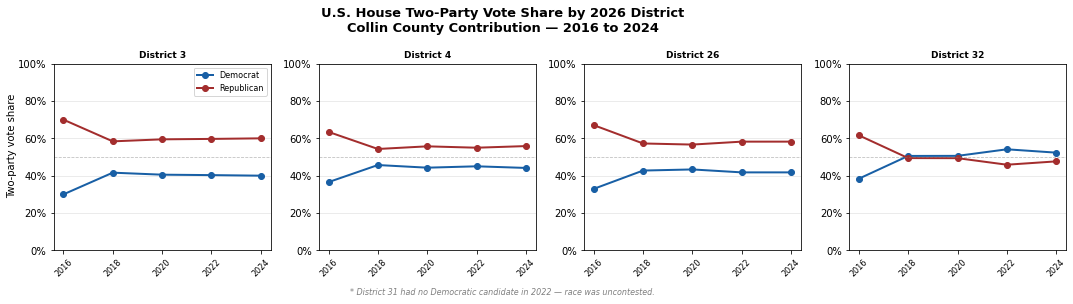

Saved figures


In [33]:
# Recalculate pivot for this county
two_party = time_series[time_series['party'].isin(['DEMOCRAT', 'REPUBLICAN'])].copy()
two_party_total = two_party.groupby(['year', 'new_district_id', 'party'])['estimated_votes'].sum().reset_index()
pivot = two_party_total.pivot_table(
    index=['year', 'new_district_id'], 
    columns='party', 
    values='estimated_votes'
).reset_index()
pivot.columns.name = None
pivot['total'] = pivot['DEMOCRAT'] + pivot['REPUBLICAN']
pivot['dem_share'] = pivot['DEMOCRAT'] / pivot['total'] * 100
pivot['rep_share'] = pivot['REPUBLICAN'] / pivot['total'] * 100

# No District 35 separation needed for Williamson — all districts are 2026 districts
pivot_2026 = pivot.copy()
districts_2026 = sorted(pivot_2026['new_district_id'].unique())
years = sorted(pivot['year'].unique())

print(f"Districts: {districts_2026}")
print(f"Years: {years}")

# Determine grid size based on number of districts
n_districts = len(districts_2026)
n_cols = 4
n_rows = (n_districts + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, district in enumerate(districts_2026):
    ax = axes[i]
    d = pivot_2026[pivot_2026['new_district_id'] == district]
    
    ax.plot(d['year'], d['dem_share'], color='#185FA5', marker='o', linewidth=2, label='Democrat')
    ax.plot(d['year'], d['rep_share'], color='#A32D2D', marker='o', linewidth=2, label='Republican')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    ax.set_title(f'District {district}', fontweight='bold', fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=8)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.text(0.07, 0.5, 'Two-party vote share', va='center', rotation='vertical', fontsize=10)
plt.suptitle(f'U.S. House Two-Party Vote Share by 2026 District\n{COUNTY_NAME.title()} County Contribution — 2016 to 2024',
             fontsize=13, fontweight='bold')
fig.text(0.5, -0.02, '* District 31 had no Democratic candidate in 2022 — race was uncontested.', 
         ha='center', fontsize=8, style='italic', color='gray')
plt.tight_layout(rect=[0.07, 0, 1, 1])
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_vote_share_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figures")

## Step 10 — Maps

Choropleth maps showing U.S. House two-party vote share by 2026 congressional 
district within Travis County — 2016 to 2024.

Data represents Travis County voter contributions only, not full district results.

In [34]:
# =============================================================================
# STEP 10 — Maps
# =============================================================================

# Load 2026 districts and clip to county boundary
county_boundary = precincts_2020.dissolve()  # Dissolve all precincts into one county boundary shape
districts_clipped = gpd.clip(districts.to_crs(precincts_2020.crs), county_boundary)
print(f"Clipped districts: {len(districts_clipped)}")
print(f"Districts: {sorted(districts_clipped['District'].unique())}")

Clipped districts: 4
Districts: [3, 4, 26, 32]


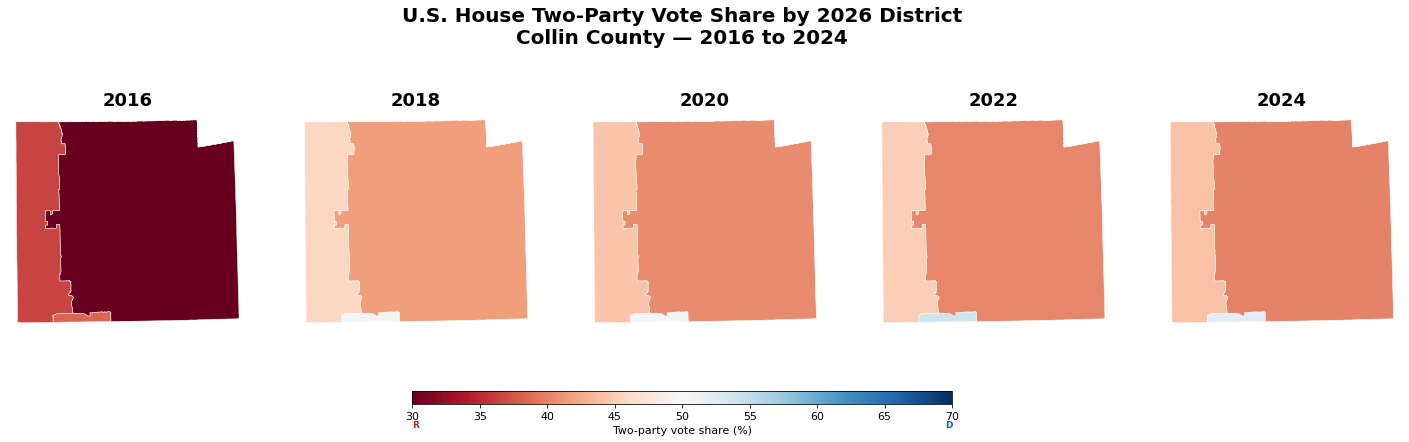

Saved map


In [35]:
years_to_plot = [2016, 2018, 2020, 2022, 2024]

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
for i, year in enumerate(years_to_plot):
    ax = axes[i]
    
    year_data = pivot_2026[pivot_2026['year'] == year][['new_district_id', 'dem_share']].copy()
    year_data.columns = ['District', 'dem_share']
    
    districts_year = districts_clipped.merge(year_data, on='District', how='left')
    
    districts_year.plot(
        column='dem_share',
        ax=ax,
        cmap='RdBu',
        vmin=30,
        vmax=70,
        legend=False,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_title(f'{year}', fontweight='bold', fontsize=18)
    ax.set_axis_off()
    
    # Zoom into county bounds
    bounds = districts_clipped.total_bounds
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=30, vmax=70))
sm.set_array([])
cbar_ax = fig.add_axes([0.35, 0.08, 0.3, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Two-party vote share (%)', fontsize=11)
cbar.ax.text(0, -1.8, 'R', transform=cbar.ax.transAxes, fontsize=9, color='#A32D2D', fontweight='bold')
cbar.ax.text(1, -1.8, 'D', transform=cbar.ax.transAxes, fontsize=9, color='#185FA5', fontweight='bold', ha='right')

plt.suptitle(f'U.S. House Two-Party Vote Share by 2026 District\n{COUNTY_NAME.title()} County — 2016 to 2024',
             fontsize=20, fontweight='bold', y=1.0)
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved map")

In [36]:
# =============================================================================
# Change map — 2016 to 2024 shift in two-party vote share
# =============================================================================

# Get 2016 and 2024 dem share
dem_2016 = pivot_2026[pivot_2026['year'] == 2016][['new_district_id', 'dem_share']].copy()
dem_2024 = pivot_2026[pivot_2026['year'] == 2024][['new_district_id', 'dem_share']].copy()

# Calculate delta
change = dem_2016.merge(dem_2024, on='new_district_id', suffixes=('_2016', '_2024'))
change['delta'] = change['dem_share_2024'] - change['dem_share_2016']
change.columns = ['District', 'dem_2016', 'dem_2024', 'delta']
print(change[['District', 'dem_2016', 'dem_2024', 'delta']].round(1).to_string())

   District  dem_2016  dem_2024  delta
0         3      30.0      40.0   10.0
1         4      36.6      44.1    7.6
2        26      32.9      41.8    8.8
3        32      38.4      52.3   14.0


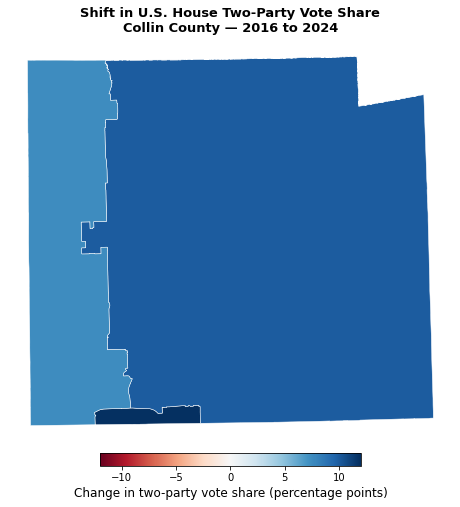

Saved change map


In [37]:
# Build change map
districts_change = districts_clipped.merge(change, on='District', how='left')
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
districts_change.plot(
    column='delta',
    ax=ax,
    cmap='RdBu',
    vmin=-12,
    vmax=12,
    legend=False,
    edgecolor='white',
    linewidth=0.5
)
ax.set_axis_off()

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=-12, vmax=12))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02)
cbar.set_label('Change in two-party vote share (percentage points)', fontsize=12)

plt.title(f'Shift in U.S. House Two-Party Vote Share\n{COUNTY_NAME.title()} County — 2016 to 2024',
          fontsize=13, fontweight='bold')
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_change_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved change map")

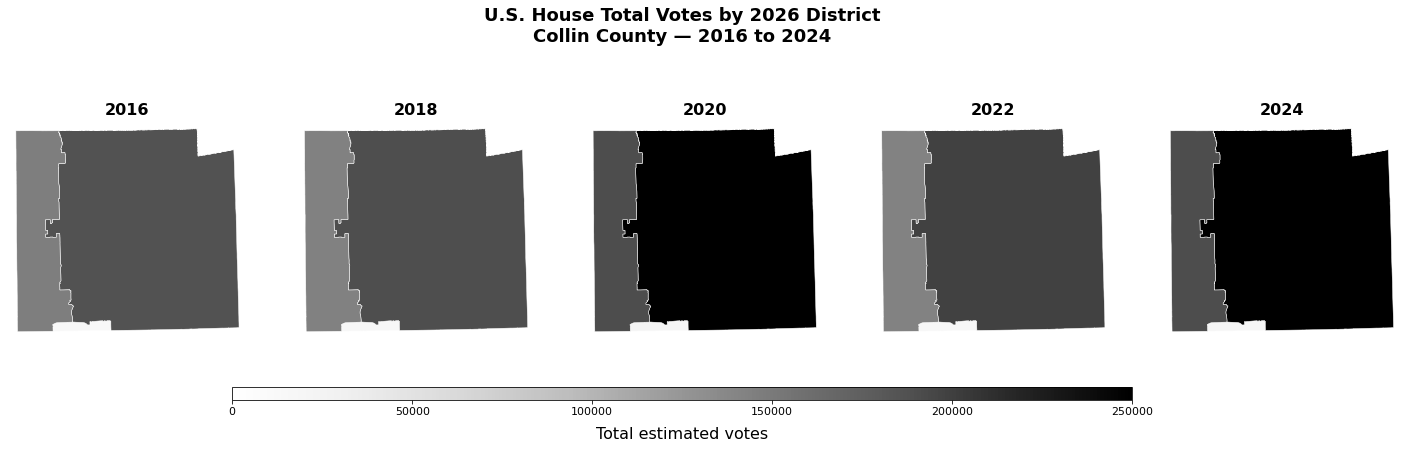

Saved turnout map


In [38]:
# =============================================================================
# Turnout map — total estimated votes per district per year
# =============================================================================
turnout = time_series.groupby(['year', 'new_district_id'])['estimated_votes'].sum().reset_index()
turnout.columns = ['year', 'District', 'total_votes']

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
for i, year in enumerate(years_to_plot):
    ax = axes[i]
    
    year_data = turnout[turnout['year'] == year][['District', 'total_votes']].copy()
    districts_year = districts_clipped.merge(year_data, on='District', how='left')
    
    districts_year.plot(
        column='total_votes',
        ax=ax,
        cmap='Greys',
        vmin=0,
        vmax=250000,
        legend=False,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_title(f'{year}', fontweight='bold', fontsize=16)
    ax.set_axis_off()
    
    bounds = districts_clipped.total_bounds
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=0, vmax=250000))
sm.set_array([])
cbar_ax = fig.add_axes([0.25, 0.11, 0.5, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Total estimated votes', fontsize=16, labelpad=10)

plt.suptitle(f'U.S. House Total Votes by 2026 District\n{COUNTY_NAME.title()} County — 2016 to 2024',
             fontsize=18, fontweight='bold', y=1.02)
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_turnout_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved turnout map")